In [84]:
import numpy as np
import pandas as pd
#loading CASCADE simulations
data = np.load (
    '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Erosional_Sink/OCR_I_Status_Quo_S0_Erosional_Sink.npz', allow_pickle=True)
data

NpzFile '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Erosional_Sink/OCR_I_Status_Quo_S0_Erosional_Sink.npz' with keys: cascade

In [85]:
cascade_object = data['cascade'][0]

In [86]:
# cascade_object.barrier3d[34].RSLR
# Get the RSLR time series from the first Barrier3D model
rslr_time_series = cascade_object.barrier3d[0].RSLR

# Calculate the cumulative sum to get total RSLR at each year
total_rslr = np.cumsum(rslr_time_series)

# Define the years you want to check
years_to_check = [ 24, 49, 74, 99] #-1 index

print("--- Total Sea Level Rise (m) from Simulation ---")
for year in years_to_check:
    # Python uses 0-based indexing, so we subtract 1
    index = year - 1
    if index < len(total_rslr):
        print(f"Year {year}: {total_rslr[index]:.3f} m")



--- Total Sea Level Rise (m) from Simulation ---
Year 24: 0.020 m
Year 49: 0.053 m
Year 74: 0.096 m
Year 99: 0.145 m


In [88]:
#exporting road elevations for aech domain categorized by the years

results_list = []
target_years = [24, 49, 74, 99]

if not cascade_object.roadways:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")
else:
    for year in target_years:
        for i, road_segment in enumerate(cascade_object.roadways):
            elevation_time_series = road_segment._road_ele_TS
            
            if year < len(elevation_time_series):
                elevation = elevation_time_series[year]
                
                result_row = {
                    'Year': year,
                    'Domain': i,
                    'Road_Elevation': elevation
                }
                results_list.append(result_row)
                
            else:
                print(f"Data for Year {year}, Domain {i} is not available.")

#convert the list to a DataFrame and save it
if results_list:
    # Convert the list of dictionaries into a pandas DataFrame
    results_df = pd.DataFrame(results_list)
    output_filename = 'I scenario/Erosional_Sink/OCR_I_Status_Quo_S0_Erosional_Sink_RoadElevation.csv'

    results_df.to_csv(output_filename, index=False)
    print(results_df.head()) 


   Year  Domain  Road_Elevation
0    24       0             0.0
1    24       1             0.0
2    24       2             0.0
3    24       3             0.0
4    24       4             0.0


In [76]:
#load the csv files for road elvation and water level
road_elevation = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Erosional_Sink/OCR_I_Status_Quo_S0_Erosional_Sink_RoadElevation.csv'
water_level_NAVD = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/Daily_WL_NAVD.csv'
road_df = pd.read_csv(road_elevation)
water_NAVD_df = pd.read_csv(water_level_NAVD)

In [77]:
import pandas as pd
# Daily_WL_MHW = pd.read_csv('/CASCADE/scripts/FLOOD ANALYSIS/Daily_WL_MHW.csv')
Daily_WL_NAVD = pd.read_csv('/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/Daily_WL_NAVD.csv')

In [78]:
#daily max water level (NAVD)
daily_tidal_levels_NAVD= water_NAVD_df['v'].values
daily_tidal_MHW = daily_tidal_levels_NAVD - 0.26


 Loading data and running analysis:
Successfully loaded all input files (skipped header in water level file).
Analysis complete. Results saved to 'I scenario/Erosional_Sink/OCR_I_Status_Quo_S0_Erosional_Sink_flood.csv'
  > Plot saved as 'Heatmap_OCR_I_Status_Quo_S0_Erosional_Sink.png'


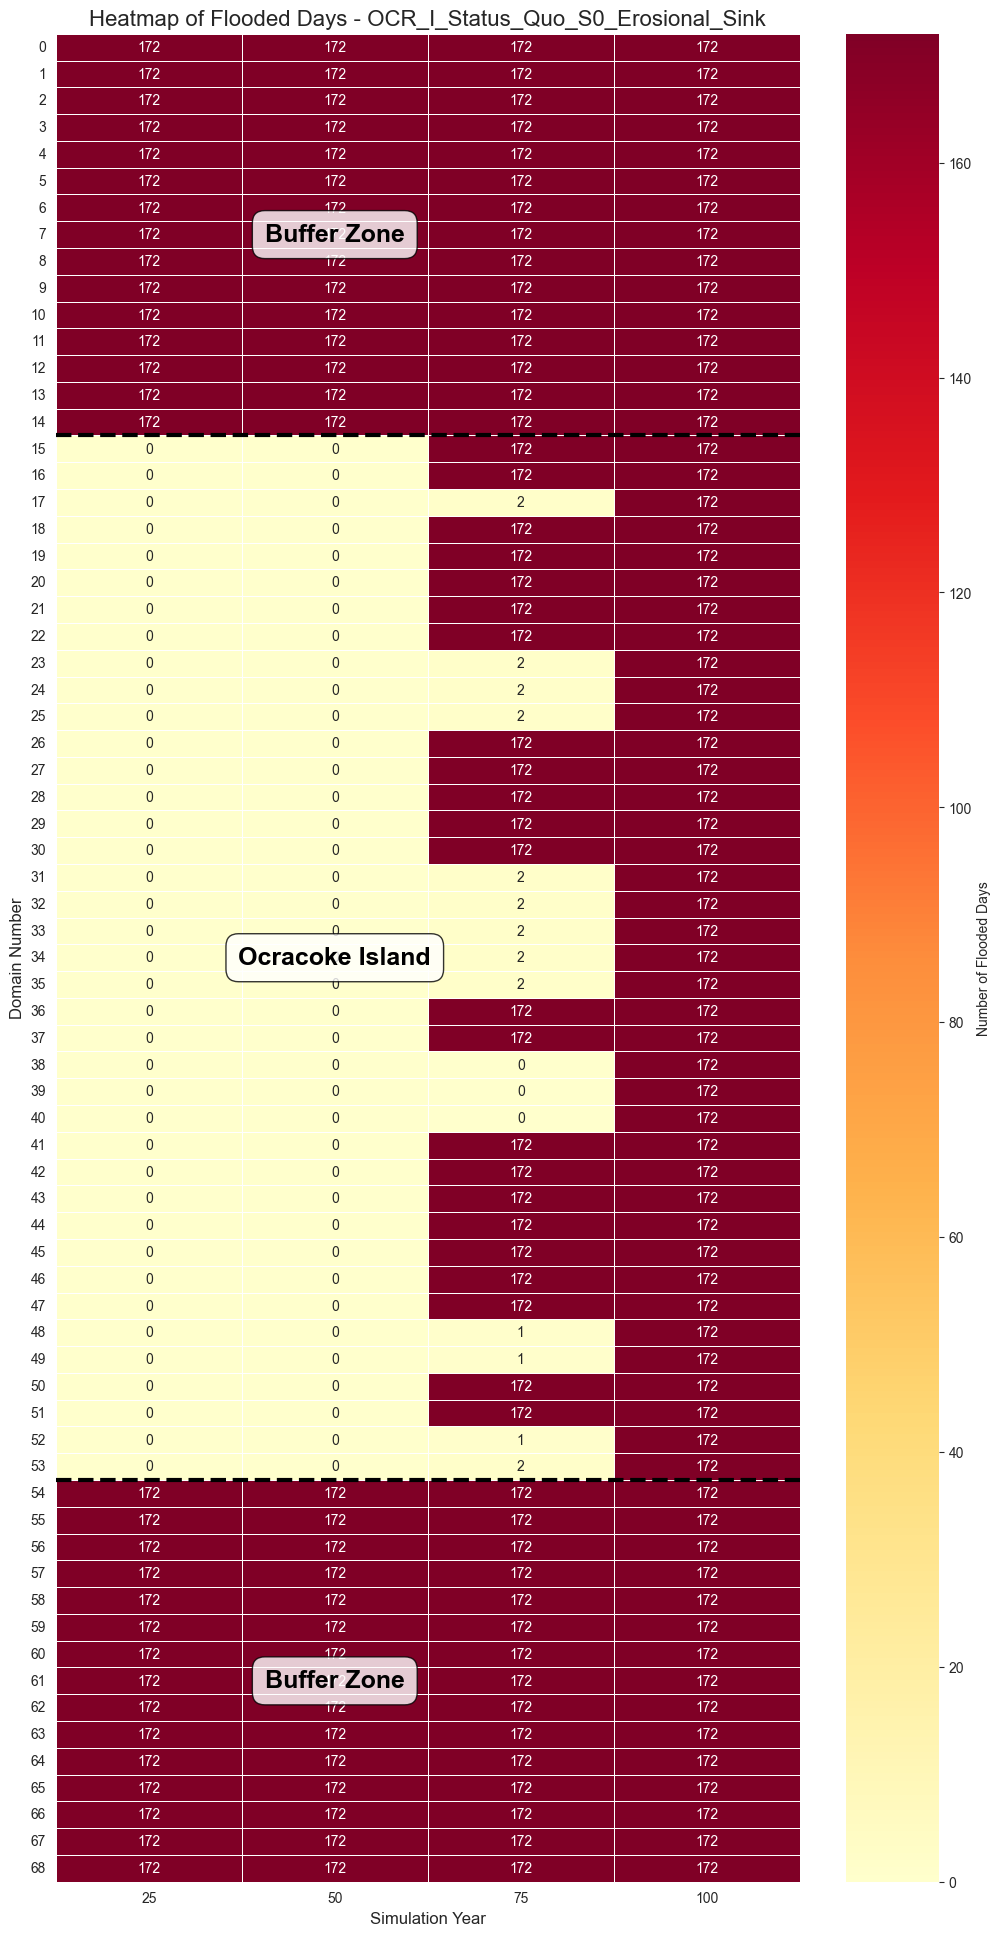

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#read the road elev and tidal water levels and specify a file name to output

analysis_output_filepath = 'I scenario/Erosional_Sink/OCR_I_Status_Quo_S0_Erosional_Sink_flood.csv'
MHW_ELEVATION_NAVD88 = 0.26  # The MHW value for your site in meters NAVD88
print(f"\n Loading data and running analysis:")
part1_success = False
results_df = None
print("Successfully loaded all input files (skipped header in water level file).")

# Perform the comparison
final_results = []
for index, road_row in road_df.iterrows():
    year = int(road_row['Year'])
    domain = int(road_row['Domain'])
    road_elevation = road_row['Road_Elevation']
    flooded_days = np.sum(road_elevation < daily_tidal_MHW)
    
    result_row = {
        'Year': year,
        'Domain': domain,
        'Road_Elevation_m': road_elevation,
        'Flooded_Days': flooded_days,
    }
    final_results.append(result_row)

# Save the analysis results to a CSV file

results_df = pd.DataFrame(final_results)
results_df.to_csv(analysis_output_filepath, index=False)
print(f"Analysis complete. Results saved to '{analysis_output_filepath}'")

heatmap_data = results_df.pivot_table(index='Domain', columns='Year', values='Flooded_Days')

plt.figure(figsize=(12, 24))
sns.set_style("whitegrid")
ax = sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='YlOrRd', linewidths=.5, cbar_kws={'label': 'Number of Flooded Days'})

ax.axhline(y=15, color='black', linestyle='--', linewidth=3)
ax.axhline(y=54, color='black', linestyle='--', linewidth=3)
ax.set_xticklabels(['25', '50', '75', '100'])

text_props = dict(ha='center', va='center', fontsize=18, color='black', weight='bold')
bbox_props = dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=1, alpha=0.8)

plt.text(1.5, 7.5, 'Buffer Zone', **text_props, bbox=bbox_props)
plt.text(1.5, 34.5, 'Ocracoke Island', **text_props, bbox=bbox_props)
plt.text(1.5, 61.5, 'Buffer Zone', **text_props, bbox=bbox_props)



plt.title(f'Heatmap of Flooded Days - OCR_I_Status_Quo_S0_Erosional_Sink', fontsize=16)
plt.xlabel('Simulation Year', fontsize=12)
plt.ylabel('Domain Number', fontsize=12)
plt.yticks(rotation=0)

plot_output_filename = f'Heatmap_OCR_I_Status_Quo_S0_Erosional_Sink.png'
plt.savefig(plot_output_filename, bbox_inches='tight')
print(f"  > Plot saved as '{plot_output_filename}'")
plt.show() # Close the figure to avoid displaying multiple plots at once
